In [1]:
from sklearn.datasets import load_digits

In [2]:
digits = load_digits()              #Returns a scikit-learn Bunch object containing the digits data and information about the Digits dataset

In [3]:
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [4]:
digits.target[::100]

array([0, 4, 1, 7, 4, 8, 2, 2, 4, 4, 1, 9, 7, 3, 2, 1, 2, 5])

In [5]:
digits.data.shape

(1797, 64)

In [6]:
digits.target.shape

(1797,)

In [7]:
digits.images[13]       #Two dimensional 8-by-8 (8 width, 8 height), representing a digit image's pixel intensities

array([[ 0.,  2.,  9., 15., 14.,  9.,  3.,  0.],
       [ 0.,  4., 13.,  8.,  9., 16.,  8.,  0.],
       [ 0.,  0.,  0.,  6., 14., 15.,  3.,  0.],
       [ 0.,  0.,  0., 11., 14.,  2.,  0.,  0.],
       [ 0.,  0.,  0.,  2., 15., 11.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  2., 15.,  4.,  0.],
       [ 0.,  1.,  5.,  6., 13., 16.,  6.,  0.],
       [ 0.,  2., 12., 12., 13., 11.,  0.,  0.]])

In [8]:
digits.data[13]

array([ 0.,  2.,  9., 15., 14.,  9.,  3.,  0.,  0.,  4., 13.,  8.,  9.,
       16.,  8.,  0.,  0.,  0.,  0.,  6., 14., 15.,  3.,  0.,  0.,  0.,
        0., 11., 14.,  2.,  0.,  0.,  0.,  0.,  0.,  2., 15., 11.,  0.,
        0.,  0.,  0.,  0.,  0.,  2., 15.,  4.,  0.,  0.,  1.,  5.,  6.,
       13., 16.,  6.,  0.,  0.,  2., 12., 12., 13., 11.,  0.,  0.])

In [9]:
import matplotlib.pyplot as plt

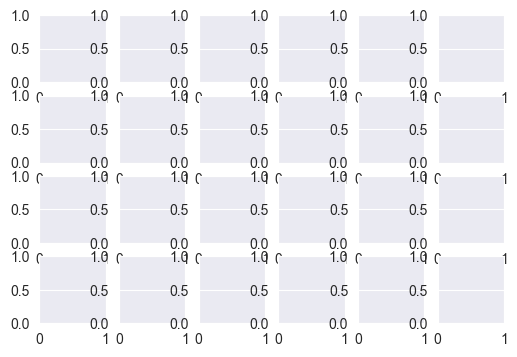

In [10]:
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(6,4))            #Crea 6-by-4 inch Figure (figsize=(6,4)). Return the Axes objects in a 2-Dimensional Numpy Array, and Figure shows the Figure with labels

In [11]:
#Iterate through the 24 Axes objects to display each 24 images

In [12]:
for item in zip(axes.ravel(), digits.images, digits.target):        #Iterate in paraller through Axes objects, 24 first images in digits.images, and 24 values in digits.target.
    #The Numpy array method ravel creates one-dimensional view of a multidimensional array
    axes, image, target = item
    axes.imshow(image, cmap=plt.cm.gray_r)              #Display one image. cmap is the colors displayed in the images. We use grayscale, with 0 as white, 16 as black, and values between is gray
    axes.set_xticks([])                 #Remove x-axis ticks marks
    axes.set_yticks([])                 #Remove y-axis ticks marks
    axes.set_title(target)              #Show the target value above the image
plt.tight_layout()                      #Remove extra whitespaces at the Figure's top right, bottom and left, so the images can fill more of the Figure


<Figure size 640x480 with 0 Axes>

In [13]:
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


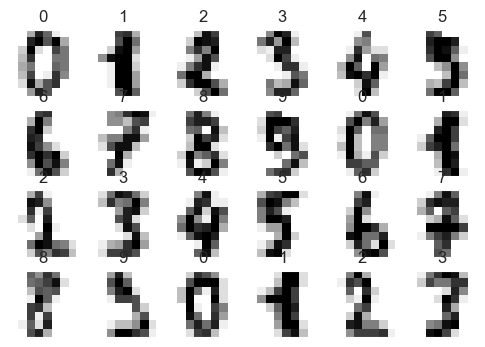

In [14]:
figure

In [15]:
from sklearn.model_selection import train_test_split            #Break the data into a training set and a testing set to prepare to train and test the model

In [16]:
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state=11)        #random_state is for reproducibility: select the same data for the training and testing same

In [17]:
#train_test_split reserves 75% of the data for training and 25% for testing, you can use keywords arguments test_size and train_size in train_test_split to change this with float 0.0-1.0

In [18]:
X_train.shape

(1347, 64)

In [19]:
X_test.shape

(450, 64)

In [20]:
#Implementing the K-Nearest neighbors algorithm

In [21]:
from sklearn.neighbors import KNeighborsClassifier

In [22]:
knn = KNeighborsClassifier()

In [23]:
knn.fit(X=X_train, y=y_train)           #Loads the sample training set and target training set

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [24]:
#n_neighbors = k in the k-nearest neighbors algorithm. By default is 5

In [25]:
predicted = knn.predict(X=X_test)

In [26]:
expected = y_test

In [27]:
predicted[:20]

array([0, 4, 9, 9, 3, 1, 4, 1, 5, 0, 4, 9, 4, 1, 5, 3, 3, 8, 5, 6])

In [28]:
expected[:20]

array([0, 4, 9, 9, 3, 1, 4, 1, 5, 0, 4, 9, 4, 1, 5, 3, 3, 8, 3, 6])

In [29]:
wrong = [(p,e) for (p,e) in zip(predicted, expected) if p!= e]

In [30]:
wrong

[(np.int64(5), np.int64(3)),
 (np.int64(8), np.int64(9)),
 (np.int64(4), np.int64(9)),
 (np.int64(7), np.int64(3)),
 (np.int64(7), np.int64(4)),
 (np.int64(2), np.int64(8)),
 (np.int64(9), np.int64(8)),
 (np.int64(3), np.int64(8)),
 (np.int64(3), np.int64(8)),
 (np.int64(1), np.int64(8))]

In [31]:
print(f'{knn.score(X_test, y_test):.2%}')           #Returns the prediction accuracy

97.78%


In [32]:
#Using confusion matrix to show the correct and incorrect predicted values for a given class

In [33]:
from sklearn.metrics import confusion_matrix

In [34]:
confusion = confusion_matrix(y_true=expected, y_pred=predicted)     #y_true = specifies the test samples' actual classes, y_pred = specifies the predicted digits for those test images

In [35]:
confusion           #Correct predictions are shown on the diagonal (principal diagonal). The nonzero values that are not on the principal diagonal indicate incorrect predictions

array([[45,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 45,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 54,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 42,  0,  1,  0,  1,  0,  0],
       [ 0,  0,  0,  0, 49,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0, 38,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 42,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 45,  0,  0],
       [ 0,  1,  1,  2,  0,  0,  0,  0, 39,  1],
       [ 0,  0,  0,  0,  1,  0,  0,  0,  1, 41]])

In [36]:
#Each row represents one distinct class. The columns specify how many of the test samples were classified into each distinct class.
#row 0 represents the digit 0 class and has 10 possible target classes (as columns) 0 through 9
#row 0 -> 45 test samples were classified as the digit 0 and none of the test samples were misclassified as any of the digits 1 - 9. So 100% of the 0s were correctly predicted

#row 8 (for the digit 8) -> 1 was incorrectly classified as a 1, 1 as a 2, 2 as a 3, 39 were correctly classified as 8, 1 incorrectly as a 9
#row 8 were predicted 88.63%

In [37]:
#Classification report

In [38]:
from sklearn.metrics import classification_report

In [39]:
names = [str(digit) for digit in digits.target_names]

In [40]:
print(classification_report(expected, predicted, target_names=names))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.98      1.00      0.99        45
           2       0.98      1.00      0.99        54
           3       0.95      0.95      0.95        44
           4       0.98      0.98      0.98        50
           5       0.97      1.00      0.99        38
           6       1.00      1.00      1.00        42
           7       0.96      1.00      0.98        45
           8       0.97      0.89      0.93        44
           9       0.98      0.95      0.96        43

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



In [41]:
#precision: total number of correct predictions / total number of predictions for that digit
#recall: total number of correct prediction / total number of samples that should have been predicted as that digit
#f1-socre: average of the precision and the recall
#support: The number of samples with a given expected value

In [42]:
#Visualization the Confusion Matrix

In [43]:
import pandas as pd

In [44]:
confusion_df = pd.DataFrame(confusion, index=range(10), columns=range(10))

In [45]:
confusion_df

,0,1,2,3,4,5,6,7,8,9
0,45,0,0,0,0,0,0,0,0,0
1,0,45,0,0,0,0,0,0,0,0
2,0,0,54,0,0,0,0,0,0,0
3,0,0,0,42,0,1,0,1,0,0
4,0,0,0,0,49,0,0,1,0,0
5,0,0,0,0,0,38,0,0,0,0
6,0,0,0,0,0,0,42,0,0,0
7,0,0,0,0,0,0,0,45,0,0
8,0,1,1,2,0,0,0,0,39,1
9,0,0,0,0,1,0,0,0,1,41


In [46]:
import seaborn as sns

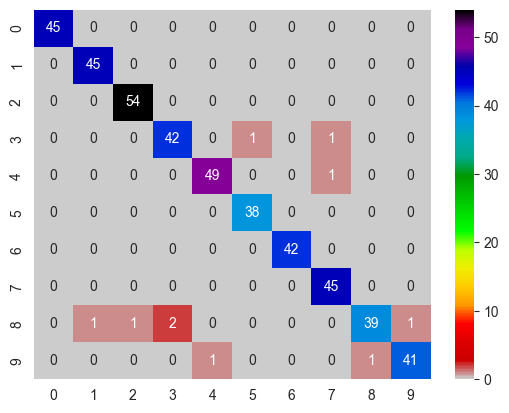

In [47]:
axes = sns.heatmap(confusion_df, annot=True, cmap='nipy_spectral_r')

In [48]:
#annot=True -> display a color bar to the right of the diagram.

In [49]:
#Creating a KFold object to perform k-fold cross-validation

In [50]:
from sklearn.model_selection import KFold

In [51]:
kfold = KFold(n_splits=10, random_state=11, shuffle=True)

In [52]:
#n_splist = specifies the number of folds
#random_state = seeds the random number generator for reproducibility
#shuffle = True -> randomize the data by shuffling it before splitting it into folds

In [53]:
#Training and testing the model

In [54]:
from sklearn.model_selection import cross_val_score

In [55]:
scores = cross_val_score(estimator=knn, X=digits.data, y=digits.target, cv=kfold)   #Returns an array of accuracy scores, one for each fold

In [56]:
#estimator -> specifies the estimator you'd like to validate
#X -> specifies the samples to use for training and testing
#Y = specifies the target predictions for the sample
#cv -> specifies the cross-validation generator that defines how to split the samples and targets for training and testing

In [57]:
scores

array([0.97777778, 0.99444444, 0.98888889, 0.97777778, 0.98888889,
       0.99444444, 0.97777778, 0.98882682, 1.        , 0.98324022])

In [58]:
print(f'Mean accuracy: {scores.mean():.2%}')

Mean accuracy: 98.72%


In [59]:
print(f'Accuracy standard deviation: {scores.std():.2%}')

Accuracy standard deviation: 0.75%


In [60]:
#Running multiple models: SVC and GaussianNB to find the best one

In [61]:
from sklearn.svm import SVC

In [62]:
from sklearn.naive_bayes import GaussianNB

In [63]:
estimators = {
    'KNeighborsClassifier': knn,
    'SVC': SVC(gamma='scale'),
    'GaussianNB': GaussianNB(),
}

In [64]:
#Executing the models

In [65]:
for estimator_name, estimator_object in estimators.items():             #Iterate through items in the dictionary
    kfold = KFold(n_splits=10, random_state=11, shuffle=True)           #Shuffles the data and produces 10 folds, each works with identical folds
    scores = cross_val_score(estimator=estimator_object, X=digits.data, y=digits.target, cv=kfold)      #Evaluates the current estimator_object using cross_val_score
    print(f'{estimator_name:>20}: ' +
          f'mean accuracy={scores.mean():.2%}; ' +
          f'standard deviation={scores.std():.2%}')

KNeighborsClassifier: mean accuracy=98.72%; standard deviation=0.75%
                 SVC: mean accuracy=98.72%; standard deviation=0.79%
          GaussianNB: mean accuracy=84.48%; standard deviation=3.47%


In [66]:
#Hyperparameter Tuning

In [68]:
#Create KNN Classifiers with odd K values from 1 through 19 and performs k-fold cross-validation on each

In [69]:
for k in range(1,20,2):
    kfold = KFold(n_splits=10, random_state=11, shuffle=True)
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(estimator=knn, X=digits.data, y=digits.target, cv=kfold)
    print(f'k={k:<2}; mean accuracy={scores.mean():.2%}; ' +
          f'standard deviation={scores.std():.2%}')


k=1 ; mean accuracy=98.83%; standard deviation=0.58%
k=3 ; mean accuracy=98.83%; standard deviation=0.72%
k=5 ; mean accuracy=98.72%; standard deviation=0.75%
k=7 ; mean accuracy=98.44%; standard deviation=0.96%
k=9 ; mean accuracy=98.39%; standard deviation=0.80%
k=11; mean accuracy=98.33%; standard deviation=0.90%
k=13; mean accuracy=97.89%; standard deviation=0.89%
k=15; mean accuracy=97.89%; standard deviation=1.02%
k=17; mean accuracy=97.50%; standard deviation=1.00%
k=19; mean accuracy=97.66%; standard deviation=0.96%
